# Financial Performance Comparison: Online vs Offline Retail
## ACC102 Mini Assignment Track 2
Amazon (AMZN) & Walmart (WMT) | 2015-2025

## 1. Project Overview
This project compares financial performance differences between **online e-commerce Amazon (AMZN)** and traditional offline physical retailer Walmart (WMT).
Four core financial indicators are analysed:
- Total Revenue
- Net Income
- Net Profit Margin
- Year-on-Year Revenue Growth Rate

Data source: WRDS Compustat Database, sample period: 2015-2025

In [44]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data Acquisition
Connect to WRDS database and extract annual financial statement data of two listed companies.

In [45]:
username = "haojiagu0111"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


## 3. Financial Indicator Calculation
1. Convert date format and extract annual data
2. Net Profit Margin = Net Income / Total Revenue
3. YoY Revenue Growth = (Current Revenue - Previous Revenue) / Previous Revenue


In [46]:
data = db.raw_sql("""
    SELECT
        gvkey,
        tic,
        conm,
        datadate,
        csho,
        sale,
        ni,
        rect,
        at
    FROM
        comp.funda
    WHERE
        tic IN ('AMZN','WMT')
        AND datadate >= '2015-01-01'
        AND datadate <= '2025-12-31'
        AND datafmt = 'STD'
        AND indfmt = 'INDL'
        AND popsrc = 'D'
    ORDER BY
        tic, datadate
""")

data

,gvkey,tic,conm,datadate,csho,sale,ni,rect,at
0,064768,AMZN,AMAZON.COM INC,2015-12-31,471.0,107006.0,596.0,4400.0,65444.0
1,064768,AMZN,AMAZON.COM INC,2016-12-31,477.0,135987.0,2371.0,6561.0,83402.0
2,064768,AMZN,AMAZON.COM INC,2017-12-31,484.0,177866.0,3033.0,9692.0,131310.0
3,064768,AMZN,AMAZON.COM INC,2018-12-31,491.0,232887.0,10073.0,13310.0,162648.0
4,064768,AMZN,AMAZON.COM INC,2019-12-31,498.0,280522.0,11588.0,17663.0,225248.0
5,064768,AMZN,AMAZON.COM INC,2020-12-31,503.0,386064.0,21331.0,19981.0,321195.0
6,064768,AMZN,AMAZON.COM INC,2021-12-31,509.0,469822.0,33364.0,26500.0,420549.0
7,064768,AMZN,AMAZON.COM INC,2022-12-31,10242.0,513983.0,-2722.0,34800.0,462675.0
8,064768,AMZN,AMAZON.COM INC,2023-12-31,10383.0,574785.0,30425.0,46900.0,527854.0
9,064768,AMZN,AMAZON.COM INC,2024-12-31,10593.0,637959.0,59248.0,49300.0,624894.0


## 4. Visual Analysis

In [47]:
data['datadate'] = pd.to_datetime(data['datadate'], errors='coerce')
data['year'] = data['datadate'].dt.year
data['net_margin'] = data['ni'] / data['sale']
data['rev_growth'] = data.groupby('tic')['sale'].pct_change()
result = data[['tic','year','conm','sale','ni','net_margin','rev_growth']]
print(result)

     tic  year            conm      sale       ni  net_margin  rev_growth
0   AMZN  2015  AMAZON.COM INC  107006.0    596.0     0.00557        <NA>
1   AMZN  2016  AMAZON.COM INC  135987.0   2371.0    0.017435    0.270835
2   AMZN  2017  AMAZON.COM INC  177866.0   3033.0    0.017052    0.307963
3   AMZN  2018  AMAZON.COM INC  232887.0  10073.0    0.043253     0.30934
4   AMZN  2019  AMAZON.COM INC  280522.0  11588.0    0.041309    0.204541
5   AMZN  2020  AMAZON.COM INC  386064.0  21331.0    0.055252    0.376234
6   AMZN  2021  AMAZON.COM INC  469822.0  33364.0    0.071014    0.216954
7   AMZN  2022  AMAZON.COM INC  513983.0  -2722.0   -0.005296    0.093995
8   AMZN  2023  AMAZON.COM INC  574785.0  30425.0    0.052933    0.118296
9   AMZN  2024  AMAZON.COM INC  637959.0  59248.0    0.092871    0.109909
10  AMZN  2025  AMAZON.COM INC  716924.0  77670.0    0.108338    0.123778
11   WMT  2015     WALMART INC  483521.0  16363.0    0.033841        <NA>
12   WMT  2016     WALMART INC  479962

In [48]:
plt.style.use('default')

## 4. Visual Analysis: Annual Revenue Trend

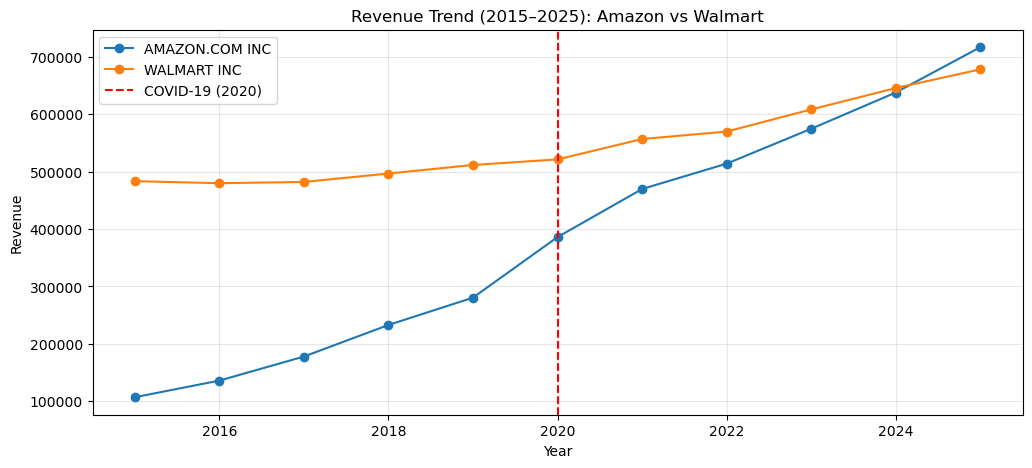

In [49]:
plt.figure(figsize=(12,5))
for tic in data['tic'].unique():
    df = data[data['tic']==tic]
    plt.plot(df['year'], df['sale'], marker='o', ms=6, label=df['conm'].iloc[0])

plt.axvline(x=2020, color='red', linestyle='--', label='COVID-19 (2020)')
plt.title('Revenue Trend (2015–2025): Amazon vs Walmart')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. Visual Analysis: Net Income Trend

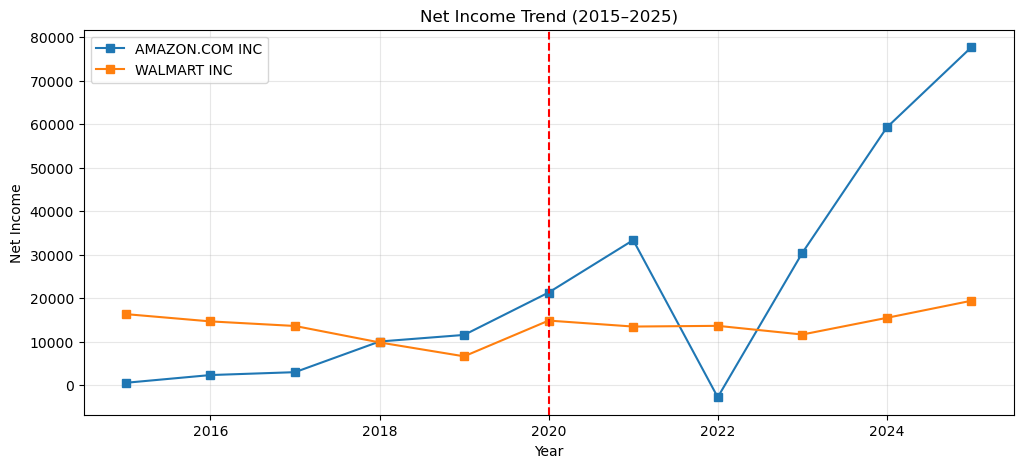

In [50]:
plt.figure(figsize=(12,5))
for tic in data['tic'].unique():
    df = data[data['tic']==tic]
    plt.plot(df['year'], df['ni'], marker='s', ms=6, label=df['conm'].iloc[0])

plt.axvline(x=2020, color='red', linestyle='--')
plt.title('Net Income Trend (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Net Income')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Visual Analysis: Net Margin Trend

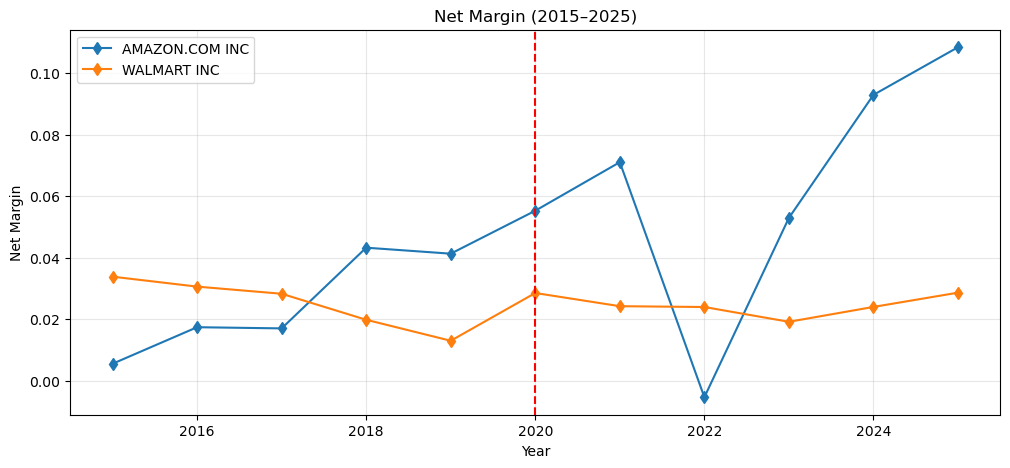

In [51]:
plt.figure(figsize=(12,5))
for tic in data['tic'].unique():
    df = data[data['tic']==tic]
    plt.plot(df['year'], df['net_margin'], marker='d', ms=6, label=df['conm'].iloc[0])

plt.axvline(x=2020, color='red', linestyle='--')
plt.title('Net Margin (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Net Margin')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. Visual Analysis: Revenue Growth Trend

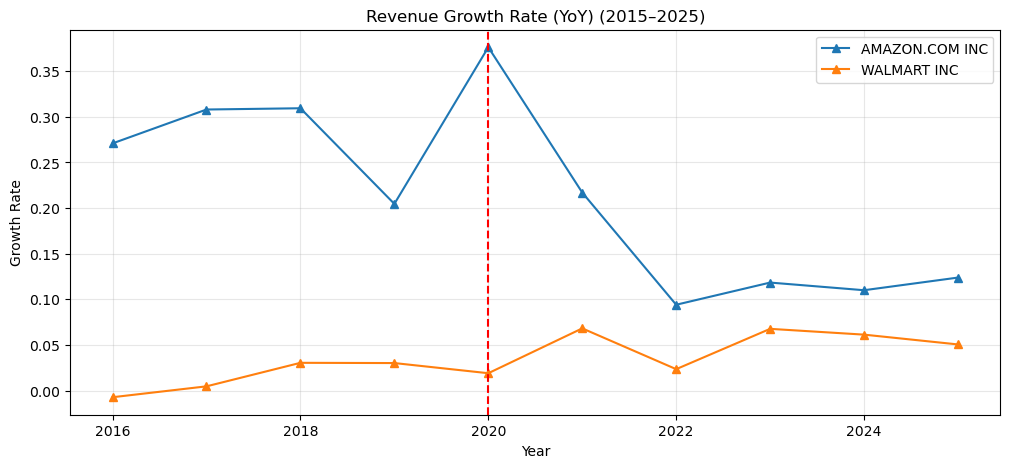

In [52]:
plt.figure(figsize=(12,5))
for tic in data['tic'].unique():
    df = data[data['tic']==tic]
    plt.plot(df['year'], df['rev_growth'], marker='^', ms=6, label=df['conm'].iloc[0])

plt.axvline(x=2020, color='red', linestyle='--')
plt.title('Revenue Growth Rate (YoY) (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Conclusion
1. Amazon online retail has higher revenue growth and greater profit volatility
2. Walmart offline retail maintains stable low growth and steady cash flow
3. COVID-19 pandemic in 2020 significantly widened the performance gap between online and offline retail industry